In [2]:
install.packages("table1")

Installing package into ‘/home/jupyter/.R/library’
(as ‘lib’ is unspecified)



In [3]:
library(bigrquery)
library(knitr)
library(tidyverse)
library(ggplot2)
library("table1")
library("IRdisplay")
bq_auth()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘table1’


The following objects are masked from ‘package:base’:

    units, units<-




In [7]:
data <-bq_dataset_query(query="
SELECT *

 FROM `yhcr-prd-phm-bia-core.CB_1935_AK.src_bmbc_CAMHS_alt`"
                       ,x="yhcr-prd-phm-bia-core.CB_1935_AK")

CAMHS <- bq_table_download(data) 

In [8]:
head(CAMHS)

person_id,birth_datetime,ethnic_group,gender_source_value,dateevent,age_at_encounter,age_band,snomedcode,ctv3code,ctv3text,lsoa,partialpostcode,tbl_srpatientaddresshistory_start_date,tbl_srpatientaddresshistory_end_date,IMD,LSOA_Name,event_year
<int>,<dttm>,<chr>,<chr>,<dttm>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<int>,<chr>,<int>
1630023,1990-11-15,White,Female,2017-04-28 00:00:00,27,25+,514341000000108,XaXIf,Referral to safeguarding children team,E01010611,SA11,2013-01-30,2013-01-30,1,Bradford 046C E01010611,2017
13276741,2000-11-15,Unknown,Female,2017-06-15 20:43:04,17,15-20,514341000000108,XaXIf,Referral to safeguarding children team,E01010702,BD21,2017-06-15,2017-06-15,1,Bradford 008C E01010702,2017
12620677,2005-02-15,Unknown,Male,2017-12-10 17:59:54,12,10-15,514341000000108,XaXIf,Referral to safeguarding children team,E01010856,BD22,2018-07-15,2018-07-15,4,Bradford 023C E01010856,2017
5136937,2008-05-15,White,Male,2017-08-03 15:44:12,9,5-10,514341000000108,XaXIf,Referral to safeguarding children team,E01010849,BD6,2020-03-06,2020-03-06,5,Bradford 059C E01010849,2017
13753126,2004-08-15,White,Male,2017-11-13 00:00:01,13,10-15,870791000000104,XaaCX,Discharge from child and adolescent mental health service,E01010644,BD6,2014-04-30,2014-04-30,7,Bradford 004G E01010644,2017
12445885,2014-06-15,White,Male,2017-07-31 13:43:07,3,0-5,514341000000108,XaXIf,Referral to safeguarding children team,E01010713,BD21,2016-08-04,2016-08-04,1,Bradford 011B E01010713,2017


In [ ]:
data1 <-bq_dataset_query(query="
select round(avg(count1),5)

from(

SELECT person_id,count(person_id) count1

 FROM `yhcr-prd-phm-bia-core.CB_MYSPACE_RS.CAMHS_alt`

 group by person_id)base"
                       ,x="yhcr-prd-phm-bia-core.CB_MYSPACE_RS")

CAMHSAVG <- bq_table_download(data1) 

In [9]:
library(forcats)

In [10]:
display_jupyter <- function(x) {
  css <- system.file("table1_defaults_1.0/table1_defaults.css", package="table1")
  css <- paste(readLines(css), collapse="\n")
  x <- htmltools::tagList(htmltools::tags$style(css), htmltools::tags$div(class="Rtable1", x))
  IRdisplay::display_html(as.character(x))
}

In [11]:
CAMHS$age_band <- factor(CAMHS$age_band, levels = c("0-5", "5-10", "10-15", "15-20", "20-25", "25+"))

In [12]:
label(CAMHS$IMD)      <- "IMD"
label(CAMHS$ethnic_group)      <- "Ethnic Group"
label(CAMHS$gender_source_value)      <- "Gender"
label(CAMHS$age_band)      <- c("Age Band")

In [13]:
 x<-table1(~ CAMHS$IMD + CAMHS$ethnic_group +CAMHS$gender_source_value +CAMHS$age_band |CAMHS$event_year,data=CAMHS
          ,justify=c("left", "left", rep("center", 5)),format_number = TRUE
          ,caption = "COS-EY 3: Mental Health - Child and Adolescent Mental Health Services (CAMHS) referrals-and-discharges:
a demographic breakdown of a Bradford Primary Care sample from Connected Bradford using OpenCodelists Snomed Codes"
         )
## Snomed Code derived by Dr Ciarán McInerney,Research Associate School of Medicine & Population Health, University of Sheffield. 
#This list of possible codes was generated by searching the SNOMED-CT vocabulary for the keywords 'CAMHS' and 'safeguarding'. The only authority this codelist has is the review by the clinical team members.
#https://www.opencodelists.org/codelist/user/ciaranmci/camhs-referrals-and-discharges/0e87f47d/


Warning message in table1.formula(~CAMHS$IMD + CAMHS$ethnic_group + CAMHS$gender_source_value + :
“Terms to the right of '|' in formula 'x' define table columns and are expected to be factors with meaningful labels.”


In [14]:
display_jupyter(x)

,2017(N=177),2018(N=218),2019(N=364),2020(N=427),2021(N=404),2022(N=408),Overall(N=1998)
IMD,,,,,,,
Mean (SD),3.77 (2.59),3.31 (2.66),3.46 (2.64),3.62 (2.79),3.56 (2.75),3.61 (2.76),3.56 (2.72)
"Median [Min, Max]","3.00 [1.00, 10.0]","2.00 [1.00, 10.0]","3.00 [1.00, 10.0]","3.00 [1.00, 10.0]","2.00 [1.00, 10.0]","3.00 [1.00, 10.0]","3.00 [1.00, 10.0]"
Ethnic Group,,,,,,,
Asian or Asian British,22 (12.4%),36 (16.5%),60 (16.5%),58 (13.6%),88 (21.8%),70 (17.2%),334 (16.7%)
Black or African or Caribbean or Black British,3 (1.7%),2 (0.9%),1 (0.3%),0 (0%),1 (0.2%),7 (1.7%),14 (0.7%)
Mixed multiple ethnic groups,5 (2.8%),3 (1.4%),14 (3.8%),19 (4.4%),17 (4.2%),14 (3.4%),72 (3.6%)
Other ethnic group,2 (1.1%),1 (0.5%),2 (0.5%),2 (0.5%),2 (0.5%),6 (1.5%),15 (0.8%)
Unknown,29 (16.4%),32 (14.7%),35 (9.6%),50 (11.7%),49 (12.1%),27 (6.6%),222 (11.1%)
White,116 (65.5%),144 (66.1%),252 (69.2%),298 (69.8%),247 (61.1%),284 (69.6%),1341 (67.1%)


In [15]:
library(dplyr)

In [20]:
CAMHS_percentage <- CAMHS %>%
  group_by(event_year) %>%
  summarise(percentage = n() / nrow(CAMHS) * 100)


CAMHS_percentage$event_year <- factor(CAMHS_percentage$event_year, levels = as.character(2012:2023))

CAMHS_percentage<- CAMHS_percentage %>%
    mutate(output=ifelse(percentage <10,ifelse(percentage>10 ,0,NA),percentage))

OVERALL<- 
ggplot(CAMHS_percentage, aes(x = event_year, y = output, group = 1, )) +
  geom_line() +
  geom_point() +
   labs(caption = "small numbers removed")+
  labs(title = "COS-EY 3: Mental Health - CAMHS Percentage Over Time",
       x = "Event Year",
       y = "Percentage") +

scale_y_continuous(labels = function(x) paste0(x, "%"))+
               theme(panel.border = element_blank(),# panel.grid.major = element_blank(),
#panel.grid.minor = element_blank(), 
      axis.line = element_line(colour = "black"),axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))+
geom_text(aes(label = round(output,0)), hjust = 0.75,  vjust = -1) +
                   theme_minimal()+
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))+
  theme_minimal()


In [21]:
library(grid)
#library(gridtext)
library(gridExtra)

pdf('COS-EY 3: Mental Health - CAMHS Percentage Over Time.pdf',width=10, height=10)
  title <- "COS-EY 3: Mental Health - CAMHS Percentage Over Time"
grid.text(title) 
OVERALL
dev.off()


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Warning message:
“Removed 1 row containing missing values (`geom_line()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_text()`).”


png 
  2

`summarise()` has grouped output by 'event_year'. You can override using the
`.groups` argument.


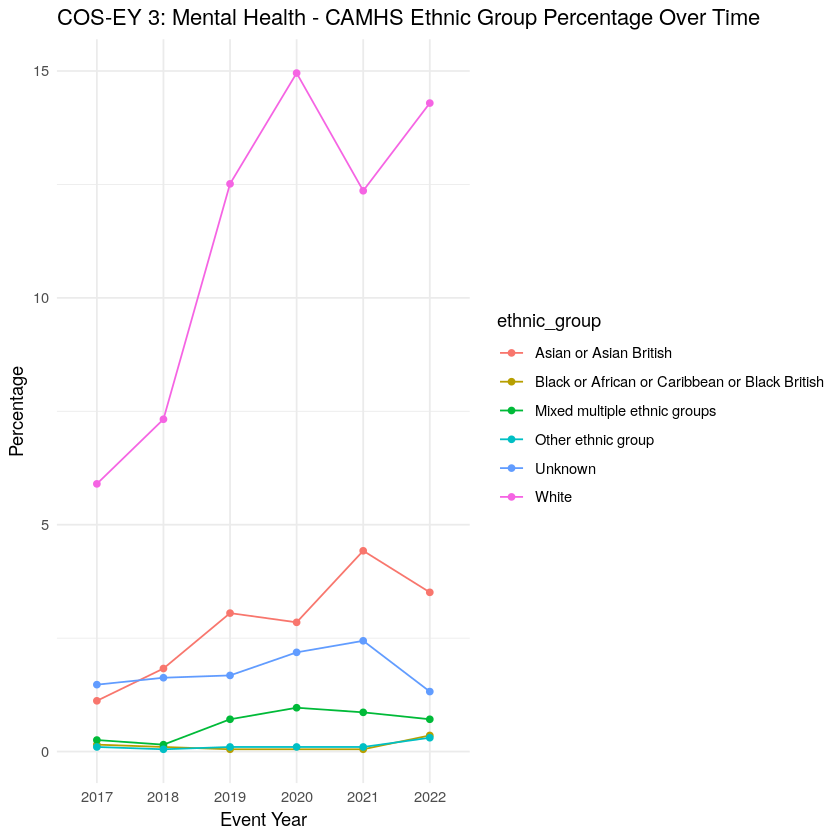

In [14]:
CAMHS_percentage <- CAMHS %>%
  group_by(event_year, ethnic_group) %>%
  summarise(percentage = n() / nrow(CAMHS) * 100)


CAMHS_percentage$event_year <- factor(CAMHS_percentage$event_year, levels = as.character(2012:2023))

ggplot(CAMHS_percentage, aes(x = event_year, y = percentage, group = ethnic_group, color = ethnic_group)) +
  geom_line() +
  geom_point() +
  labs(title = "COS-EY 3: Mental Health - CAMHS Ethnic Group Percentage Over Time",
       x = "Event Year",
       y = "Percentage") +
  theme_minimal()

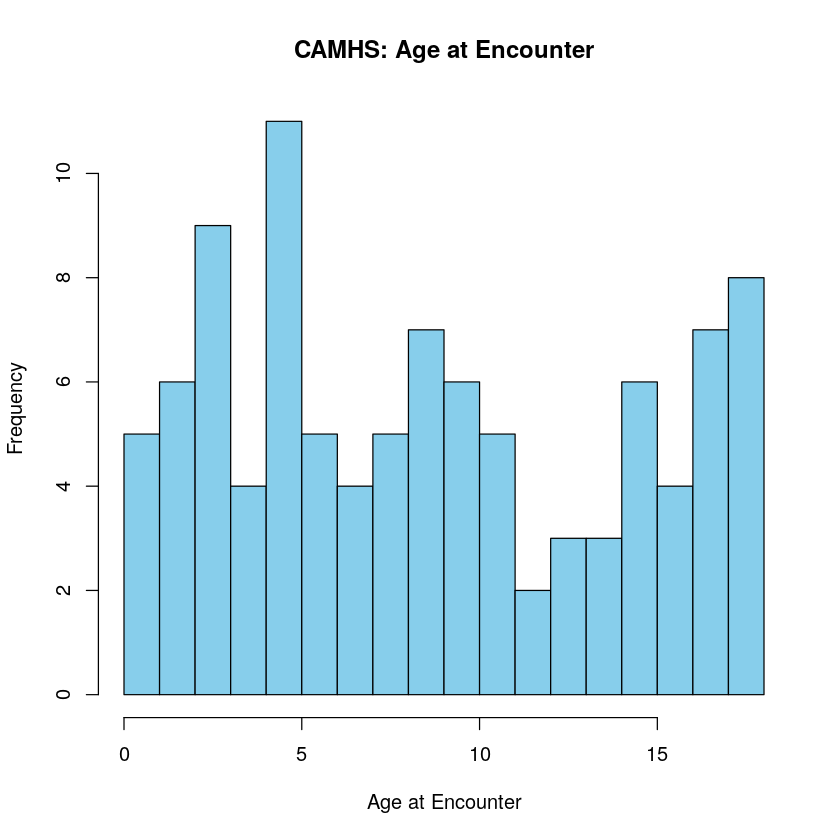

In [15]:
CAMHS <- data.frame(age_at_encounter = sample(1:18, 100, replace = TRUE))


hist(CAMHS$age_at_encounter, 
     col = "skyblue",             # Specify color
     main = "CAMHS: Age at Encounter",   # Title of the plot
     xlab = "Age at Encounter",   # X-axis label
     ylab = "Frequency",          # Y-axis label
     breaks = seq(0, max(CAMHS$age_at_encounter), by = 1))  # Specify breaks


